# 🎥 Movie Recommender System with PySpark and Visualizations

### 📦 Load and explore data

In [2]:
from os import environ
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode, split, avg, countDistinct, desc

environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17"

spark = SparkSession.builder.master("local").appName("MovieRecommender").getOrCreate()


In [3]:
ratings_path = "../data/ratings.csv"
movies_path = "../data/movies.csv"

ratings_df = spark.read.option("header", True).option("inferSchema", True).csv(ratings_path)
movies_df = spark.read.option("header", True).option("inferSchema", True).csv(movies_path)


In [4]:
ratings_df.show(10)

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|   4.0|964982703|
|     1|      3|   4.0|964981247|
|     1|      6|   4.0|964982224|
|     1|     47|   5.0|964983815|
|     1|     50|   5.0|964982931|
|     1|     70|   3.0|964982400|
|     1|    101|   5.0|964980868|
|     1|    110|   4.0|964982176|
|     1|    151|   5.0|964984041|
|     1|    157|   5.0|964984100|
+------+-------+------+---------+
only showing top 10 rows



In [5]:
movies_df.show(10)

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
|      6|         Heat (1995)|Action|Crime|Thri...|
|      7|      Sabrina (1995)|      Comedy|Romance|
|      8| Tom and Huck (1995)|  Adventure|Children|
|      9| Sudden Death (1995)|              Action|
|     10|    GoldenEye (1995)|Action|Adventure|...|
+-------+--------------------+--------------------+
only showing top 10 rows



### 🧹 Data cleaning

In [6]:
ratings_df = ratings_df.dropna().dropDuplicates()
movies_df = movies_df.dropna().dropDuplicates()


### 📊 General trends analysis

In [7]:
movie_rating_stats = (
    ratings_df.groupBy("movieId")
    .agg(avg("rating").alias("avg_rating"), countDistinct("userId").alias("num_ratings"))
)

top_rated_movies = (
    movie_rating_stats.filter(col("num_ratings") >= 100)
    .join(movies_df, "movieId")
    .orderBy(desc("avg_rating"))
    .select("title", "avg_rating", "num_ratings")
)

top_rated_movies.show(10, truncate=False)


+--------------------------------+-----------------+-----------+
|title                           |avg_rating       |num_ratings|
+--------------------------------+-----------------+-----------+
|Shawshank Redemption, The (1994)|4.429022082018927|317        |
|Godfather, The (1972)           |4.2890625        |192        |
|Fight Club (1999)               |4.272935779816514|218        |
|Godfather: Part II, The (1974)  |4.25968992248062 |129        |
|Departed, The (2006)            |4.252336448598131|107        |
|Goodfellas (1990)               |4.25             |126        |
|Casablanca (1942)               |4.24             |100        |
|Dark Knight, The (2008)         |4.238255033557047|149        |
|Usual Suspects, The (1995)      |4.237745098039215|204        |
|Princess Bride, The (1987)      |4.232394366197183|142        |
+--------------------------------+-----------------+-----------+
only showing top 10 rows



### 📈 Visualizations with seaborn

C:\Users\User\AppData\Local\Temp\ipykernel_2564\1446135545.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_movies_pd.head(10), x="avg_rating", y="title", palette="viridis")


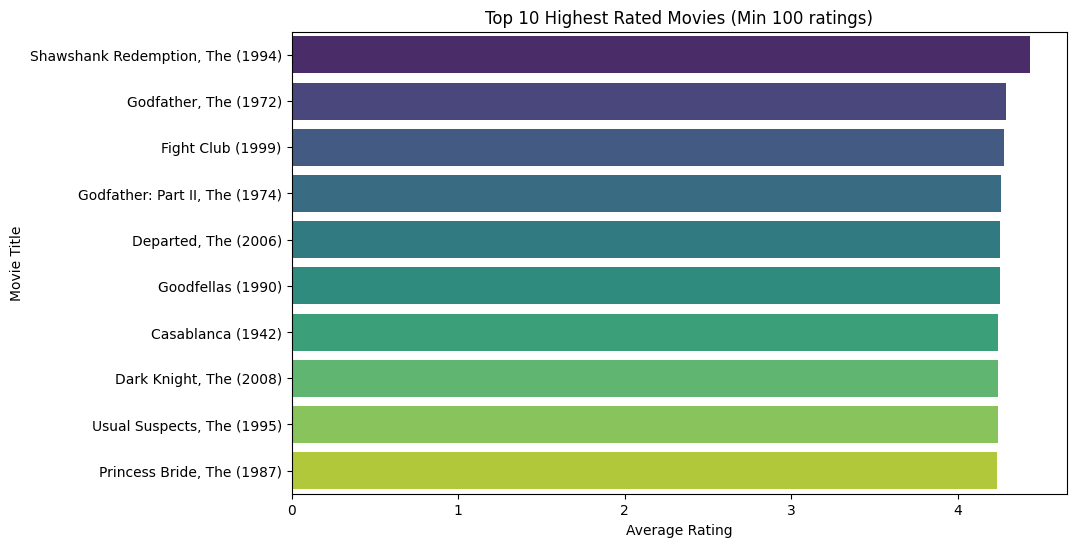

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import setuptools

top_movies_pd = top_rated_movies.toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_movies_pd.head(10), x="avg_rating", y="title", palette="viridis")
plt.title("Top 10 Highest Rated Movies (Min 100 ratings)")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.show()


In [9]:
movies_with_genres = movies_df.withColumn("genre", explode(split(col("genres"), "\|")))

popular_genres = (
    movies_with_genres.groupBy("genre")
    .count()
    .orderBy(desc("count"))
)

popular_genres.show()


<>:1: SyntaxWarning: invalid escape sequence '\|'
<>:1: SyntaxWarning: invalid escape sequence '\|'
C:\Users\User\AppData\Local\Temp\ipykernel_2564\1578507115.py:1: SyntaxWarning: invalid escape sequence '\|'
  movies_with_genres = movies_df.withColumn("genre", explode(split(col("genres"), "\|")))


+------------------+-----+
|             genre|count|
+------------------+-----+
|             Drama| 4361|
|            Comedy| 3756|
|          Thriller| 1894|
|            Action| 1828|
|           Romance| 1596|
|         Adventure| 1263|
|             Crime| 1199|
|            Sci-Fi|  980|
|            Horror|  978|
|           Fantasy|  779|
|          Children|  664|
|         Animation|  611|
|           Mystery|  573|
|       Documentary|  440|
|               War|  382|
|           Musical|  334|
|           Western|  167|
|              IMAX|  158|
|         Film-Noir|   87|
|(no genres listed)|   34|
+------------------+-----+



C:\Users\User\AppData\Local\Temp\ipykernel_2564\1333957340.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=popular_genres_pd, x="count", y="genre", palette="cubehelix")


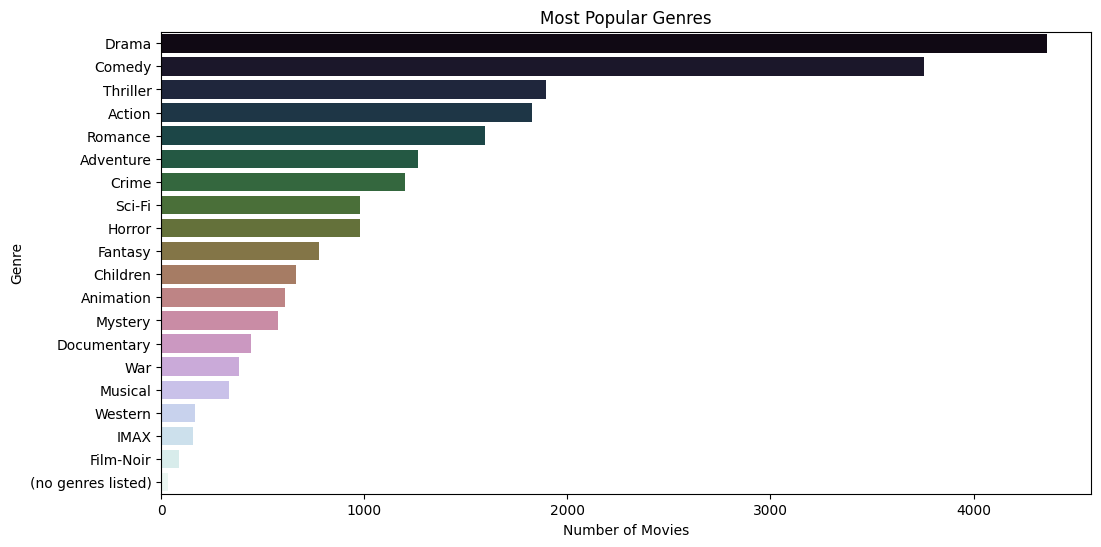

In [10]:
popular_genres_pd = popular_genres.toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(data=popular_genres_pd, x="count", y="genre", palette="cubehelix")
plt.title("Most Popular Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()


### 🧠 ALS Model Training

In [11]:
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

(training_df, test_df) = ratings_df.randomSplit([0.8, 0.2], seed=42)

als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    nonnegative=True,
    coldStartStrategy="drop"
)

model = als.fit(training_df)
predictions = model.transform(test_df)

evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print(f"RMSE = {rmse:.4f}")


RMSE = 0.8762


### 🧬 Content-Based Recommendation (TF-IDF on genres)

In [12]:
from pyspark.ml.feature import CountVectorizer, IDF
from pyspark.ml.linalg import Vectors
from pyspark.sql.functions import col, udf, desc, split
from pyspark.sql.types import DoubleType
import math

movies_tokenized = movies_df.withColumn("genre_tokens", split(col("genres"), "\\|"))

cv = CountVectorizer(inputCol="genre_tokens", outputCol="raw_features")
cv_model = cv.fit(movies_tokenized)
featurized = cv_model.transform(movies_tokenized)

idf = IDF(inputCol="raw_features", outputCol="features")
idf_model = idf.fit(featurized)
tfidf_movies = idf_model.transform(featurized)

toy_story_vec = tfidf_movies.filter(col("title") == "Toy Story (1995)").select("features").head().features

def cosine_sim(vec1, vec2):
    dot = float(vec1.dot(vec2))
    norm1 = float(vec1.norm(2))
    norm2 = float(vec2.norm(2))
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return dot / (norm1 * norm2)

cosine_sim_udf = udf(lambda x: cosine_sim(toy_story_vec, x), DoubleType())

# similar_movies = tfidf_movies.withColumn("similarity", cosine_sim_udf(col("features")))

# similar_movies.select("title", "genres", "similarity") \
#     .orderBy(desc("similarity")) \
#     .show(10, truncate=False)


### 🧑‍🤝‍🧑 User-based Recommendation (KNN)

In [13]:
user_movie_matrix = ratings_df.groupBy("userId", "movieId").agg(avg("rating").alias("rating"))
movie_ids = ratings_df.select("movieId").distinct().orderBy("movieId").rdd.map(lambda r: r[0]).collect()
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

def build_user_vector(user_ratings):
    vec = [0.0] * len(movie_ids)
    for movie_id, rating in user_ratings:
        idx = movie_id_to_index[movie_id]
        vec[idx] = rating
    return Vectors.dense(vec)

from pyspark.sql import Row
user_vectors = (
    user_movie_matrix.rdd
    .map(lambda row: (row["userId"], (row["movieId"], row["rating"])))
    .groupByKey()
    .mapValues(list)
    .mapValues(build_user_vector)
    .map(lambda x: Row(userId=x[0], features=x[1]))
)

user_vector_df = spark.createDataFrame(user_vectors)

target_user_id = 1
target_vector = user_vector_df.filter(col("userId") == target_user_id).select("features").first()["features"]
user_vector_df = user_vector_df.withColumn("similarity", cosine_sim_udf(col("features"), Vectors.dense(target_vector.toArray())))

top_k_neighbors = user_vector_df.filter(col("userId") != target_user_id).orderBy(desc("similarity")).limit(5)
top_k_neighbors_ids = [row["userId"] for row in top_k_neighbors.collect()]

neighbor_ratings = ratings_df.filter(col("userId").isin(top_k_neighbors_ids))
recommended_movies = (
    neighbor_ratings.join(ratings_df.filter(col("userId") == target_user_id), "movieId", "left_anti")
    .groupBy("movieId")
    .agg(avg("rating").alias("avg_rating"))
    .join(movies_df, "movieId")
    .orderBy(desc("avg_rating"))
)

recommended_movies.select("title", "avg_rating").show(10, truncate=False)


Py4JJavaError: An error occurred while calling z:org.apache.spark.api.python.PythonRDD.collectAndServe.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 178.0 failed 1 times, most recent failure: Lost task 0.0 in stage 178.0 (TID 310) (DESKTOP-R4IGUL7 executor driver): org.apache.spark.SparkException: Python worker exited unexpectedly (crashed)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:612)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:594)
	at scala.runtime.AbstractPartialFunction.apply(AbstractPartialFunction.scala:38)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:789)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:766)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator.hasNext(PythonRunner.scala:525)
	at org.apache.spark.InterruptibleIterator.has

### 📊 Evaluation and Recommendations

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

def precision_at_k(recommendations_df, actual_df, k=10):
    window = Window.partitionBy("userId").orderBy(desc("prediction"))
    top_k_pred = recommendations_df.withColumn("rank", row_number().over(window)).filter(col("rank") <= k)
    joined = top_k_pred.join(actual_df, on=["userId", "movieId"], how="inner")
    precision = joined.groupBy("userId").agg((countDistinct("movieId") / lit(k)).alias("precision"))
    return precision.agg(avg("precision")).first()[0]

def coverage(recommendations_df, total_movies_count):
    recommended_movie_ids = recommendations_df.select("movieId").distinct().count()
    return recommended_movie_ids / total_movies_count

p_at_10 = precision_at_k(predictions, test_df, k=10)
movie_count = movies_df.select("movieId").distinct().count()
cov = coverage(predictions, movie_count)

print(f"Precision@10: {p_at_10:.4f}")
print(f"Coverage: {cov:.4f}")


NameError: name 'lit' is not defined

In [15]:
from pyspark.sql.functions import rand

fictitious_users = ratings_df.select("userId").distinct().orderBy(rand()).limit(3)
fictitious_ids = [row["userId"] for row in fictitious_users.collect()]

for uid in fictitious_ids:
    user_recommendations = model.recommendForAllUsers(10).filter(col("userId") == uid)
    exploded = user_recommendations.selectExpr("userId", "explode(recommendations) as rec")                                    .select("userId", col("rec.movieId").alias("movieId"), col("rec.rating").alias("score"))                                    .join(movies_df, "movieId")                                    .select("title", "score")                                    .orderBy(desc("score"))

    print(f"\nTop recommendations for user {uid}:")
    exploded.show(10, truncate=False)



Top recommendations for user 519:
+-----------------------------------------------------------------------------------------------------------------------------+--------+
|title                                                                                                                        |score   |
+-----------------------------------------------------------------------------------------------------------------------------+--------+
|Saving Face (2004)                                                                                                           |5.602244|
|Cosmos                                                                                                                       |5.415521|
|De platte jungle (1978)                                                                                                      |5.391688|
|Bitter Lake (2015)                                                                                                           |5.391688|
|Water

### 🧾 Conclusion

- **ALS** provides strong collaborative filtering performance.
- **TF-IDF based filtering** helps find content-similar movies, especially useful in cold-start scenarios.
- **KNN** offers personalized recommendations by leveraging similar users.
- **Best strategy**: use ALS for scale, and mix with content-based for richer personalization.
